# Notebook 03a: Encoder Comparison — Sum vs Attentive Message Passing

**Experimental question**: Does attention-weighted message passing outperform
plain sum aggregation?

**Controlled variables**: same CRN, same training mode (NLL / teacher forcing),
same training config, same data.

**Structure**:
1. Configuration
2. Training data
3. Train sum encoder
4. Train attentive encoder
5. Training curves
6. Learned dynamics (the money plot)
7. Trajectory quality
8. Residual analysis
9. Summary metrics

In [4]:
import time

import matplotlib.pyplot as plt
import numpy as np
import torch

plt.rcParams.update({"figure.dpi": 100, "font.size": 11})
torch.manual_seed(42)
np.random.seed(42)

## 1. Configuration

Both runs share the same CRN, SDE config, training config, and data.
The only difference is `use_attention` in `EncoderConfig`.

In [5]:
from crn_surrogate.configs.model_config import EncoderConfig, ModelConfig, SDEConfig
from crn_surrogate.configs.training_config import SchedulerType, TrainingConfig, TrainingMode
from crn_surrogate.crn.examples import birth_death, birth_death_analytical
from crn_surrogate.encoder.tensor_repr import crn_to_tensor_repr

crn        = birth_death(k_birth=2.0, k_death=0.5)   # stationary mean = var = 4
crn_repr   = crn_to_tensor_repr(crn)
analytical = birth_death_analytical(k_birth=2.0, k_death=0.5)

sde_config         = SDEConfig.from_crn(crn, d_model=32, d_hidden=64, clip_state=True)
encoder_config_sum = EncoderConfig(d_model=32, n_layers=2, use_attention=False)
encoder_config_att = EncoderConfig(d_model=32, n_layers=2, use_attention=True)

train_config = TrainingConfig(
    lr=3e-3,
    max_epochs=30,
    batch_size=4,
    n_sde_samples=8,
    n_ssa_samples=16,
    dt=0.2,
    val_every=5,
    grad_clip_norm=1.0,
    scheduler_type=SchedulerType.REDUCE_ON_PLATEAU,
    training_mode=TrainingMode.TEACHER_FORCING,  # GaussianTransitionNLL
    use_wandb=False,
)

print(f"CRN:            {crn}")
print(f"SDE:            {sde_config}")
print(f"Encoder (sum):  {encoder_config_sum}")
print(f"Encoder (att):  {encoder_config_att}")
print(f"Training:       {train_config}")
print(f"Stationary:     mean={analytical['stationary_mean']:.1f}  var={analytical['stationary_var']:.1f}")

CRN:            CRN(n_species=1, n_reactions=2, species=('A',))
SDE:            SDEConfig(d_model=32, d_hidden=64, n_noise_channels=2, n_hidden_layers=2, clip_state=True)
Encoder (sum):  EncoderConfig(d_model=32, n_layers=2, n_propensity_types=4, max_propensity_params=4)
Encoder (att):  EncoderConfig(d_model=32, n_layers=2, n_propensity_types=4, max_propensity_params=4)
Training:       TrainingConfig(lr=0.003, max_epochs=30, batch_size=4, dt=0.2, n_ssa_samples=16, scheduler=reduce_on_plateau, training_mode=teacher_forcing, use_wandb=False)
Stationary:     mean=4.0  var=4.0


## 2. Training Data

Train: 60 items × 16 SSA = 960 trajectories
Val:   20 items × 16 SSA = 320 trajectories


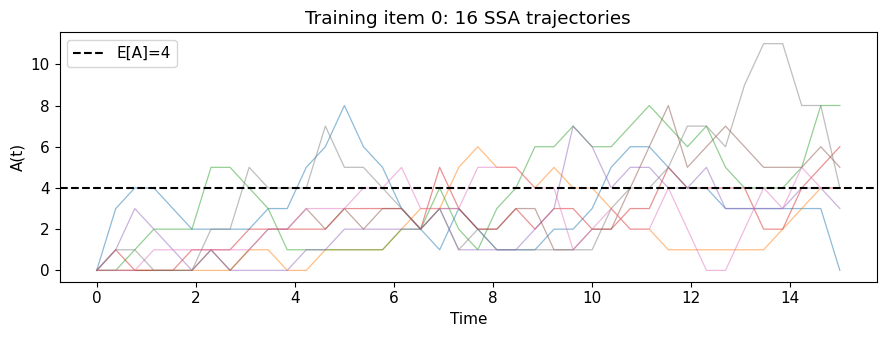

In [6]:
from crn_surrogate.data.dataset import CRNTrajectoryDataset, TrajectoryItem
from crn_surrogate.simulation import GillespieSSA, interpolate_to_grid

T_MAX   = 15.0
N_GRID  = 40
M       = train_config.n_ssa_samples
time_grid  = torch.linspace(0.0, T_MAX, N_GRID)
init_state = torch.tensor([0.0])
ssa        = GillespieSSA()


def make_dataset(n: int) -> CRNTrajectoryDataset:
    items = []
    for _ in range(n):
        trajs = []
        for _ in range(M):
            result = ssa.simulate(
                stoichiometry=crn.stoichiometry_matrix,
                propensity_fn=crn.evaluate_propensities,
                initial_state=init_state.clone(),
                t_max=T_MAX,
            )
            trajs.append(interpolate_to_grid(result.times, result.states, time_grid))
        items.append(TrajectoryItem(
            crn_repr=crn_repr,
            initial_state=init_state.clone(),
            trajectories=torch.stack(trajs),
            times=time_grid,
        ))
    return CRNTrajectoryDataset(items)


train_dataset = make_dataset(60)
val_dataset   = make_dataset(20)
print(f"Train: {len(train_dataset)} items × {M} SSA = {len(train_dataset) * M} trajectories")
print(f"Val:   {len(val_dataset)} items × {M} SSA = {len(val_dataset) * M} trajectories")

fig, ax = plt.subplots(figsize=(9, 3.5))
item = train_dataset[0]
for m in range(min(8, M)):
    ax.plot(time_grid.numpy(), item.trajectories[m, :, 0].numpy(), alpha=0.5, lw=0.9)
ax.axhline(analytical["stationary_mean"], color="black", linestyle="--", lw=1.5,
           label=f"E[A]={analytical['stationary_mean']:.0f}")
ax.set_xlabel("Time"); ax.set_ylabel("A(t)")
ax.set_title(f"Training item 0: {M} SSA trajectories")
ax.legend(); plt.tight_layout(); plt.show()

## 3. Train — Sum Encoder

In [7]:
from crn_surrogate.encoder.bipartite_gnn import BipartiteGNNEncoder
from crn_surrogate.simulator.neural_sde import CRNNeuralSDE
from crn_surrogate.training.trainer import Trainer

encoder_sum = BipartiteGNNEncoder(encoder_config_sum)
sde_sum     = CRNNeuralSDE(sde_config, n_species=1)
model_cfg_sum = ModelConfig(encoder=encoder_config_sum, sde=sde_config)

t0 = time.perf_counter()
result_sum = Trainer(encoder_sum, sde_sum, model_cfg_sum, train_config).train(train_dataset, val_dataset)
elapsed_sum = time.perf_counter() - t0
print(f"\nSum encoder: {elapsed_sum:.1f}s total  ({elapsed_sum / train_config.max_epochs:.2f}s/epoch)")

Epoch    1 | train=0.7201 | grad=1.248


Epoch    2 | train=0.5795 | grad=0.216


Epoch    3 | train=0.5762 | grad=0.106


Epoch    4 | train=0.5765 | grad=0.171


Epoch    5 | train=0.5766 | val=1.2622 | val_nll=0.5777 | grad=0.151


...

Epoch   26 | train=0.5763 | grad=0.155


Epoch   27 | train=0.5764 | grad=0.138


Epoch   28 | train=0.5759 | grad=0.123


Epoch   29 | train=0.5760 | grad=0.122


Epoch   30 | train=0.5756 | val=0.9549 | val_nll=0.5781 | grad=0.119

Sum encoder: 60.3s total  (2.01s/epoch)


## 4. Train — Attentive Encoder

In [8]:
encoder_att = BipartiteGNNEncoder(encoder_config_att)
sde_att     = CRNNeuralSDE(sde_config, n_species=1)
model_cfg_att = ModelConfig(encoder=encoder_config_att, sde=sde_config)

t0 = time.perf_counter()
result_att = Trainer(encoder_att, sde_att, model_cfg_att, train_config).train(train_dataset, val_dataset)
elapsed_att = time.perf_counter() - t0
print(f"\nAttentive encoder: {elapsed_att:.1f}s total  ({elapsed_att / train_config.max_epochs:.2f}s/epoch)")

Epoch    1 | train=0.7791 | grad=1.628


Epoch    2 | train=0.5824 | grad=0.298


Epoch    3 | train=0.5774 | grad=0.227


Epoch    4 | train=0.5763 | grad=0.170


Epoch    5 | train=0.5760 | val=0.9634 | val_nll=0.5797 | grad=0.160


...

Epoch   26 | train=0.5765 | grad=0.155


Epoch   27 | train=0.5768 | grad=0.136


Epoch   28 | train=0.5761 | grad=0.123


Epoch   29 | train=0.5761 | grad=0.143


Epoch   30 | train=0.5762 | val=1.4336 | val_nll=0.5777 | grad=0.157

Attentive encoder: 60.2s total  (2.01s/epoch)


## 5. Training Curves

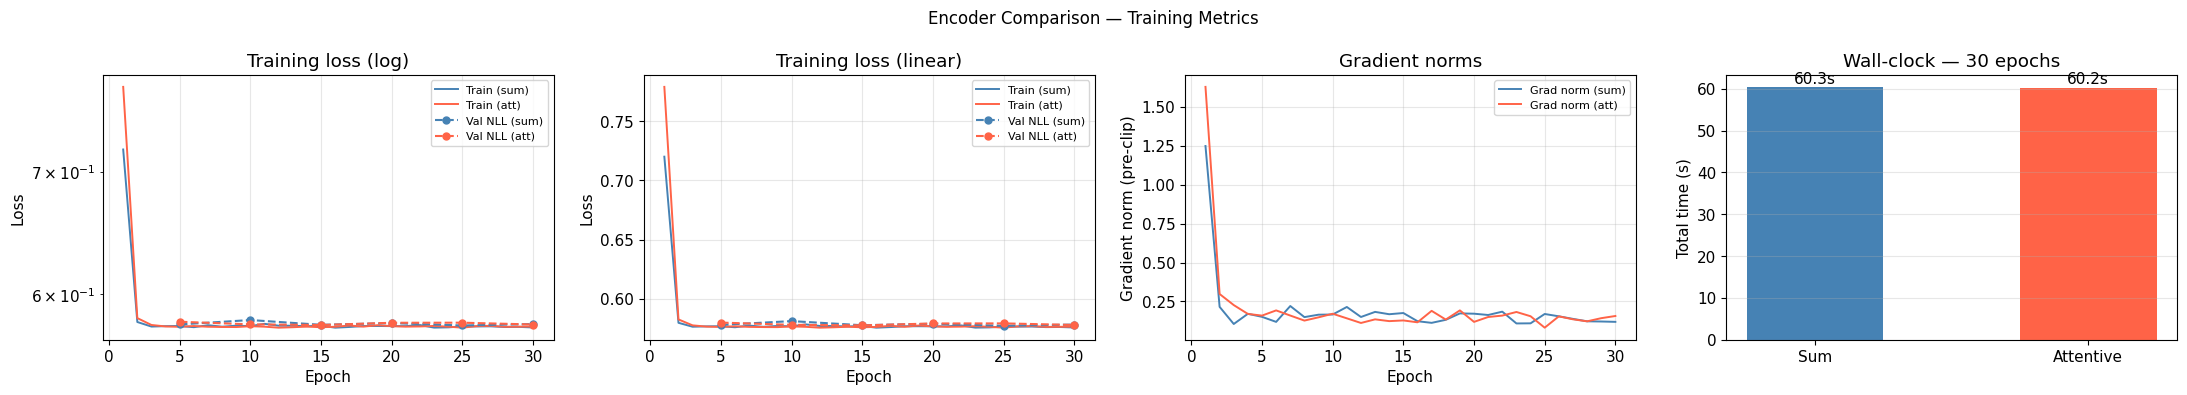

In [9]:
C_SUM = "steelblue"
C_ATT = "tomato"
epochs = range(1, train_config.max_epochs + 1)

fig, axes = plt.subplots(1, 4, figsize=(22, 4))

for ax, yscale in zip(axes[:2], ["log", "linear"]):
    ax.plot(epochs, result_sum.train_losses, color=C_SUM, lw=1.4, label="Train (sum)")
    ax.plot(epochs, result_att.train_losses, color=C_ATT, lw=1.4, label="Train (att)")
    if result_sum.val_nll_losses:
        ax.plot(result_sum.val_epochs, result_sum.val_nll_losses,
                "o--", color=C_SUM, markersize=5, label="Val NLL (sum)")
        ax.plot(result_att.val_epochs, result_att.val_nll_losses,
                "o--", color=C_ATT, markersize=5, label="Val NLL (att)")
    ax.set_xlabel("Epoch"); ax.set_ylabel("Loss"); ax.set_yscale(yscale)
    ax.set_title(f"Training loss ({yscale})"); ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

ax = axes[2]
if result_sum.grad_norms:
    ax.plot(epochs, result_sum.grad_norms, color=C_SUM, lw=1.4, label="Grad norm (sum)")
    ax.plot(epochs, result_att.grad_norms, color=C_ATT, lw=1.4, label="Grad norm (att)")
ax.set_xlabel("Epoch"); ax.set_ylabel("Gradient norm (pre-clip)")
ax.set_title("Gradient norms"); ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

ax = axes[3]
bars = ax.bar(["Sum", "Attentive"], [elapsed_sum, elapsed_att], color=[C_SUM, C_ATT], width=0.5)
for bar, val in zip(bars, [elapsed_sum, elapsed_att]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
            f"{val:.1f}s", ha="center", va="bottom", fontsize=11)
ax.set_ylabel("Total time (s)"); ax.set_title(f"Wall-clock — {train_config.max_epochs} epochs")
ax.grid(True, alpha=0.3, axis="y")

plt.suptitle("Encoder Comparison — Training Metrics", fontsize=12)
plt.tight_layout(); plt.show()

## 6. Learned Dynamics

The "money plot": did the model learn the right drift and diffusion functions?

- **Drift** should be linear and cross zero at x = k_birth/k_death = 4.
- **Diffusion** should increase with x (noise grows with population).

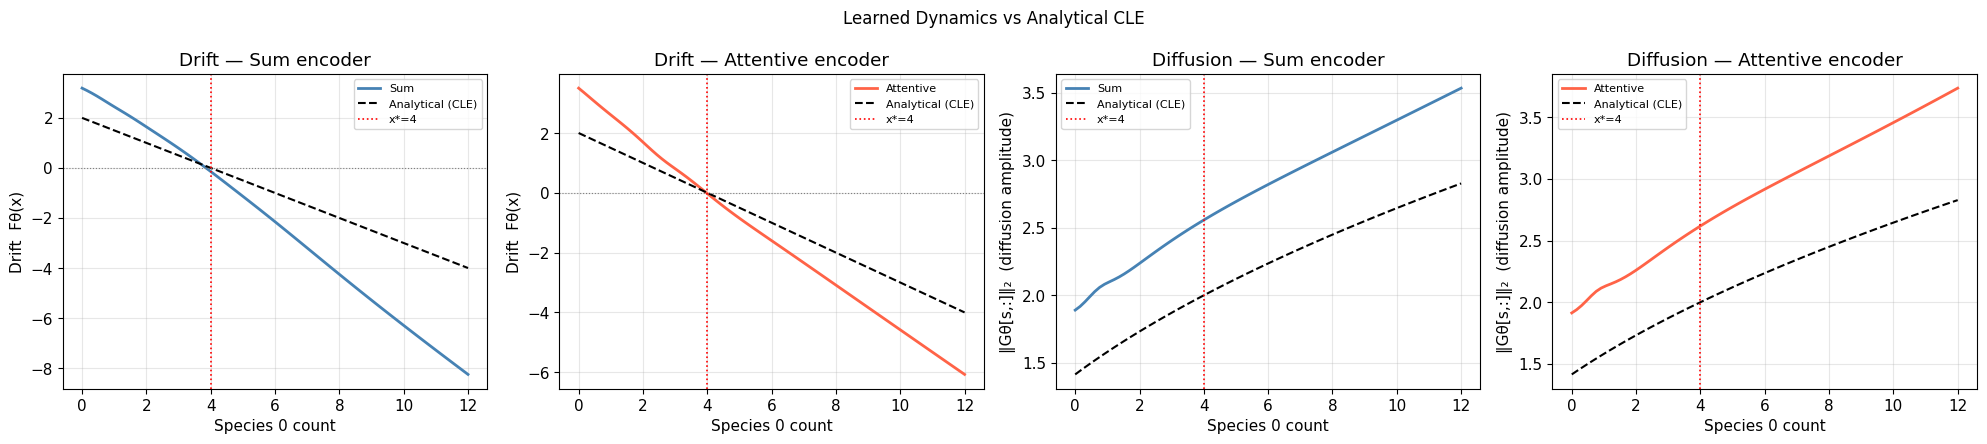

In [10]:
from crn_surrogate.evaluation import DynamicsVisualizer

state_range = torch.linspace(0.0, 12.0, 80)

viz_sum = DynamicsVisualizer(encoder_sum, sde_sum, crn_repr, init_state)
viz_att = DynamicsVisualizer(encoder_att, sde_att, crn_repr, init_state)

fig, axes = plt.subplots(1, 4, figsize=(20, 4.5))

viz_sum.plot_drift(state_range, analytical_drift_fn=analytical["drift"],
                   label="Sum", color=C_SUM, ax=axes[0])
axes[0].set_title("Drift — Sum encoder")

viz_att.plot_drift(state_range, analytical_drift_fn=analytical["drift"],
                   label="Attentive", color=C_ATT, ax=axes[1])
axes[1].set_title("Drift — Attentive encoder")

viz_sum.plot_diffusion(state_range, analytical_diffusion_fn=analytical["diffusion"],
                       label="Sum", color=C_SUM, ax=axes[2])
axes[2].set_title("Diffusion — Sum encoder")

viz_att.plot_diffusion(state_range, analytical_diffusion_fn=analytical["diffusion"],
                       label="Attentive", color=C_ATT, ax=axes[3])
axes[3].set_title("Diffusion — Attentive encoder")

for ax in axes:
    ax.axvline(analytical["stationary_mean"], color="red", linestyle=":", lw=1.2,
               label=f"x*={analytical['stationary_mean']:.0f}")
    ax.legend(fontsize=8)

plt.suptitle("Learned Dynamics vs Analytical CLE", fontsize=12)
plt.tight_layout(); plt.show()

## 7. Trajectory Quality

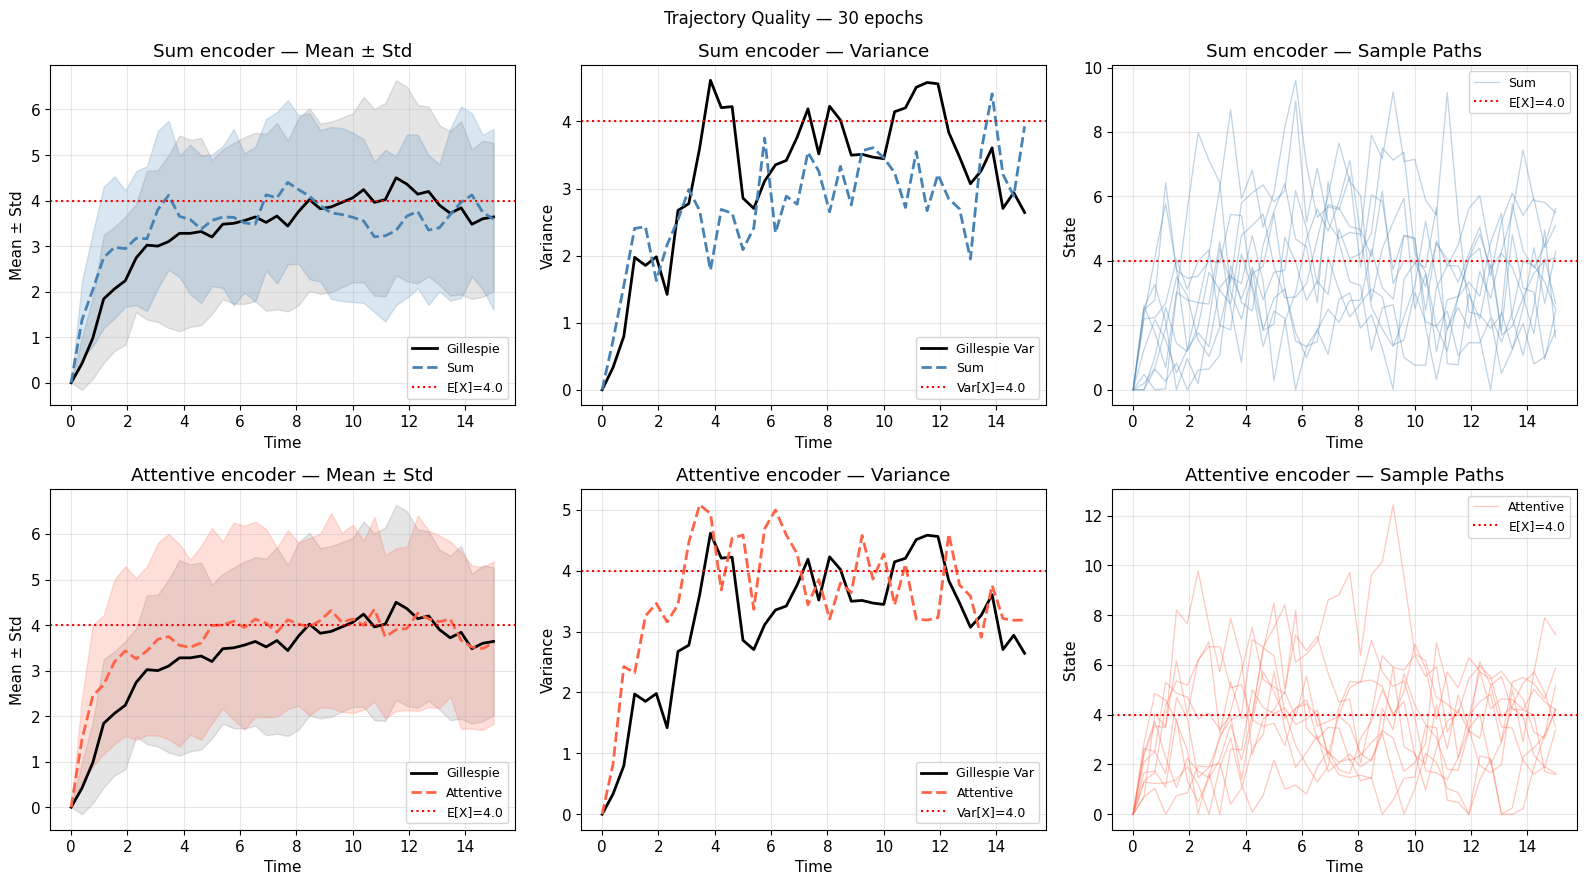

In [11]:
from crn_surrogate.evaluation import ModelEvaluator, TrajectoryComparator

eval_times = torch.linspace(0.0, T_MAX, N_GRID)
K_EVAL, M_EVAL = 50, 50

# Gillespie ground truth
ssa_trajs = []
for _ in range(M_EVAL):
    result = ssa.simulate(crn.stoichiometry_matrix, crn.evaluate_propensities,
                          init_state.clone(), T_MAX)
    ssa_trajs.append(interpolate_to_grid(result.times, result.states, eval_times))
ssa_trajs = torch.stack(ssa_trajs)  # (M_EVAL, N_GRID, 1)

evaluator_sum = ModelEvaluator(encoder_sum, sde_sum, sde_config)
evaluator_att = ModelEvaluator(encoder_att, sde_att, sde_config)

sde_trajs_sum = evaluator_sum.rollout(crn_repr, init_state, eval_times, dt=0.1, n_rollouts=K_EVAL)
sde_trajs_att = evaluator_att.rollout(crn_repr, init_state, eval_times, dt=0.1, n_rollouts=K_EVAL)

comp_sum = TrajectoryComparator(sde_trajs_sum, ssa_trajs, eval_times,
                                analytical_mean=analytical["stationary_mean"],
                                analytical_var=analytical["stationary_var"])
comp_att = TrajectoryComparator(sde_trajs_att, ssa_trajs, eval_times,
                                analytical_mean=analytical["stationary_mean"],
                                analytical_var=analytical["stationary_var"])

fig, axes = plt.subplots(2, 3, figsize=(16, 9))

kw_sum = {"sde_label": "Sum", "sde_color": C_SUM}
kw_att = {"sde_label": "Attentive", "sde_color": C_ATT}

comp_sum.plot_mean_std(**kw_sum, ax=axes[0, 0])
comp_sum.plot_variance(**kw_sum, ax=axes[0, 1])
comp_sum.plot_sample_paths(**kw_sum, ax=axes[0, 2])

comp_att.plot_mean_std(**kw_att, ax=axes[1, 0])
comp_att.plot_variance(**kw_att, ax=axes[1, 1])
comp_att.plot_sample_paths(**kw_att, ax=axes[1, 2])

for row, label in enumerate(["Sum encoder", "Attentive encoder"]):
    axes[row, 0].set_title(f"{label} — Mean ± Std")
    axes[row, 1].set_title(f"{label} — Variance")
    axes[row, 2].set_title(f"{label} — Sample Paths")

plt.suptitle(f"Trajectory Quality — {train_config.max_epochs} epochs", fontsize=12)
plt.tight_layout(); plt.show()

## 8. Residual Analysis

Standardized residuals z_s = (y_{t+1} − μ_s) / σ_s should be ~N(0,1) if the
Gaussian SDE assumption is valid. The histogram and QQ plot reveal systematic
model errors that trajectory plots cannot capture.

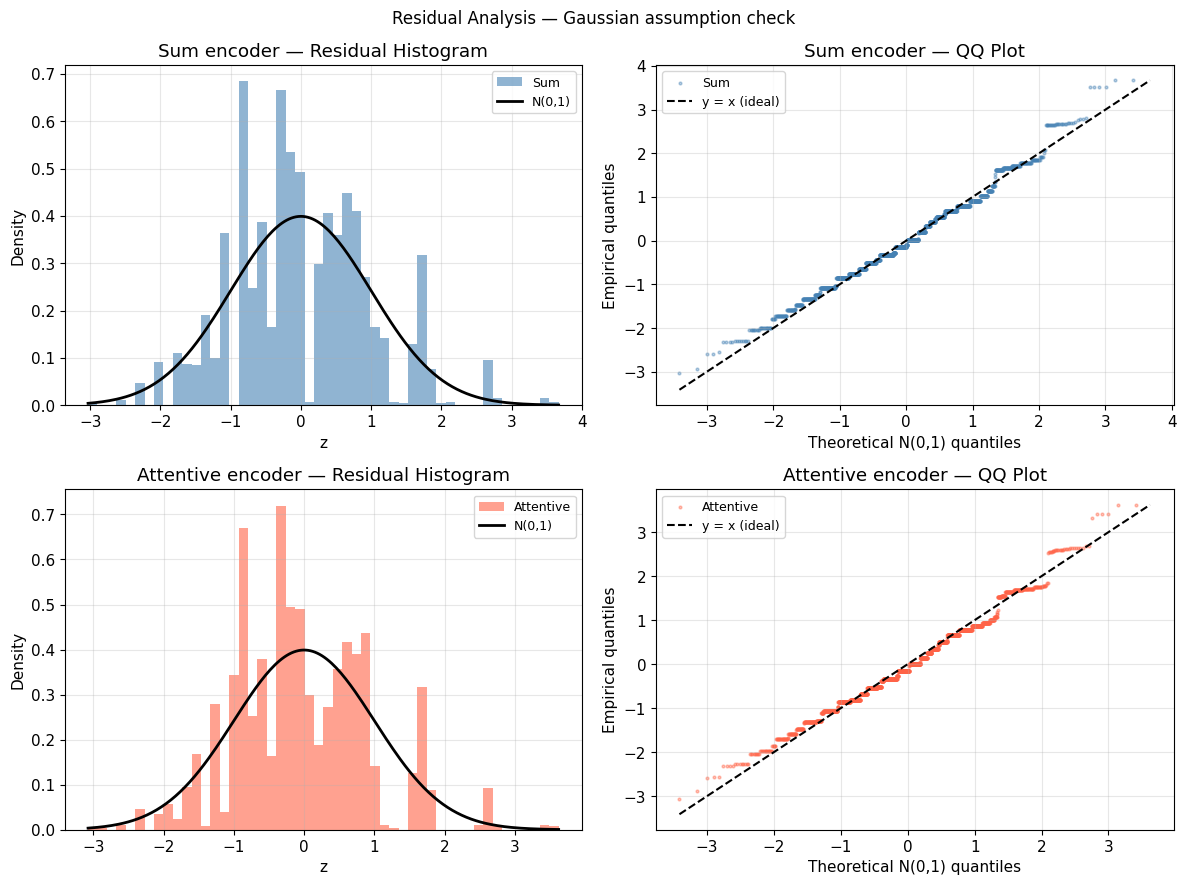

In [12]:
from crn_surrogate.evaluation import ResidualAnalyzer

analyzer_sum = ResidualAnalyzer(encoder_sum, sde_sum, crn_repr)
analyzer_att = ResidualAnalyzer(encoder_att, sde_att, crn_repr)

report_sum = analyzer_sum.compute_residuals(ssa_trajs, eval_times, dt=0.2, initial_state=init_state)
report_att = analyzer_att.compute_residuals(ssa_trajs, eval_times, dt=0.2, initial_state=init_state)

fig, axes = plt.subplots(2, 2, figsize=(12, 9))

analyzer_sum.plot_histogram(report_sum, label="Sum", color=C_SUM, ax=axes[0, 0])
analyzer_sum.plot_qq(report_sum, label="Sum", color=C_SUM, ax=axes[0, 1])
analyzer_att.plot_histogram(report_att, label="Attentive", color=C_ATT, ax=axes[1, 0])
analyzer_att.plot_qq(report_att, label="Attentive", color=C_ATT, ax=axes[1, 1])

for row, label in enumerate(["Sum encoder", "Attentive encoder"]):
    axes[row, 0].set_title(f"{label} — Residual Histogram")
    axes[row, 1].set_title(f"{label} — QQ Plot")

plt.suptitle("Residual Analysis — Gaussian assumption check", fontsize=12)
plt.tight_layout(); plt.show()

## 9. Summary Metrics

In [13]:
true_mean = analytical["stationary_mean"]
true_var  = analytical["stationary_var"]

print(f"{'Metric':<28} {'Sum':>12} {'Attentive':>12}  {'Better':>10}")
print("-" * 66)
for key in ["mean_mse", "var_mse", "final_mean", "final_var", "mean_sde_std"]:
    v_sum = comp_sum.metrics()[key]
    v_att = comp_att.metrics()[key]
    if key in ("mean_mse", "var_mse"):
        better = "Att ✓" if v_att < v_sum else "Sum ✓"
    elif key == "final_mean":
        better = f"Att Δ={abs(v_att - true_mean):.2f}" if abs(v_att - true_mean) < abs(v_sum - true_mean) else f"Sum Δ={abs(v_sum - true_mean):.2f}"
    else:
        better = ""
    print(f"{key:<28} {v_sum:>12.4f} {v_att:>12.4f}  {better:>10}")
print()
print(f"Residual mean  (→0):  Sum={report_sum.mean[0].item():.3f}  Att={report_att.mean[0].item():.3f}")
print(f"Residual std   (→1):  Sum={report_sum.std[0].item():.3f}   Att={report_att.std[0].item():.3f}")
print(f"Residual kurt  (→3):  Sum={report_sum.kurtosis[0].item():.2f}  Att={report_att.kurtosis[0].item():.2f}")
print()
print(f"Final val NLL:        Sum={result_sum.val_nll_losses[-1]:.4f}  Att={result_att.val_nll_losses[-1]:.4f}"
      if result_sum.val_nll_losses else "No val NLL recorded")

Metric                                Sum    Attentive      Better
------------------------------------------------------------------
mean_mse                           0.3386       0.3034       Att ✓
var_mse                            0.9506       0.9484       Att ✓
final_mean                         3.6626       3.8700  Att Δ=0.13
final_var                          3.1405       3.4711            
mean_sde_std                       1.6183       1.8595            

Residual mean  (→0):  Sum=0.012  Att=-0.026
Residual std   (→1):  Sum=0.975   Att=0.956
Residual kurt  (→3):  Sum=3.37  Att=3.38

Final val NLL:        Sum=0.5781  Att=0.5777
